# Assistente RAG — Edificios Verdes & Net Zero (Agua e Energia)

**Global Solution — Processamento de Linguagem Natural, Chatbots & Virtual Agents**

Assistente tecnico especializado em edificios verdes e Net Zero de energia e agua, capaz de
responder perguntas tecnicas citando sempre a fonte. Pipeline RAG totalmente local: embeddings
open-source, ChromaDB como banco vetorial e LLM via Ollama.

| Etapa | Secao |
|-------|-------|
| Planejamento e escopo | 1 |
| Construcao do corpus | 2 |
| Limpeza e normalizacao | 3 |
| Segmentacao (chunking) | 4 |
| Embeddings e indexacao | 5 |
| Pipeline RAG com LLM local | 6 |
| Avaliacao | 7 |
| Visualizacao t-SNE e insumos do relatorio | 8 |

## 0. Instalacao de dependencias

```bash
ollama pull qwen2.5:3b
```

In [1]:
# !pip install -q -r ../requirements.txt

## 1. Planejamento e escopo

Recorte tematico: edificios verdes e Net Zero abrangendo energia e agua simultaneamente —
certificacoes, geracao fotovoltaica, eficiencia energetica, automacao predial, reuso e captacao
de agua.

| Componente | Escolha | Justificativa |
|-----------|---------|---------------|
| Embedding | `intfloat/multilingual-e5-base` (768 dim) | Treinado para retrieval assimetrico (query vs passagem), forte em portugues tecnico, usa prefixos `query:` e `passage:`. Roda em CPU. |
| Banco vetorial | ChromaDB persistente | Filtro por metadados nativo (`where`), persistencia simples em disco, ideal para citacao de fontes. |
| LLM | Ollama `qwen2.5:3b` | Modelo pequeno, bom desempenho em portugues, sem dependencia de API paga. |

Estrategia anti-alucinacao: prompt de sistema restringe a resposta aos trechos recuperados e
obriga citacao no formato `[fonte, ano]` em cada afirmacao tecnica.

In [2]:
import os, re, json, unicodedata
from collections import Counter

import numpy as np
import pandas as pd

DIRETORIO_BASE      = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DIRETORIO_CORPUS    = os.path.join(DIRETORIO_BASE, 'corpus')
ARQUIVO_METADADOS   = os.path.join(DIRETORIO_BASE, 'metadata.csv')
DIRETORIO_CHROMA    = os.path.join(DIRETORIO_BASE, 'chroma_db')
DIRETORIO_SAIDAS    = os.path.join(DIRETORIO_BASE, 'saidas')
os.makedirs(DIRETORIO_SAIDAS, exist_ok=True)

MODELO_EMBEDDING = 'intfloat/multilingual-e5-base'
MODELO_LLM       = 'qwen2.5:3b'

TAMANHO_MINIMO_CHUNK   = 512
TAMANHO_MAXIMO_CHUNK   = 1024
TAMANHO_OVERLAP_CHUNK  = 80
TOP_K                  = 5

print('Diretorio base :', DIRETORIO_BASE)
print('Corpus         :', DIRETORIO_CORPUS)
print('Embedding      :', MODELO_EMBEDDING)
print('LLM            :', MODELO_LLM)

Diretorio base : F:\gsrag
Corpus         : F:\gsrag\corpus
Embedding      : intfloat/multilingual-e5-base
LLM            : qwen2.5:3b


## 2. Construcao do corpus

Carrega o arquivo `metadata.csv` e valida que cada documento listado existe em `corpus/`. Os
metadados obrigatorios sao: fonte, categoria, subcategoria (energia ou agua), ano e vigencia.

In [3]:
metadados = pd.read_csv(ARQUIVO_METADADOS)
metadados['arquivo'] = metadados['arquivo'].str.strip()

arquivos_ausentes = [a for a in metadados['arquivo'] if not os.path.exists(os.path.join(DIRETORIO_CORPUS, a))]
assert not arquivos_ausentes, f'Arquivos listados em metadata.csv mas ausentes em corpus/: {arquivos_ausentes}'
assert len(metadados) >= 10, f'Corpus tem {len(metadados)} documentos; o minimo exigido e 10.'
assert metadados['categoria'].nunique() >= 3, 'O corpus precisa conter ao menos 3 categorias distintas.'

print(f'Total de documentos: {len(metadados)}')
print('\nDistribuicao por categoria:'); print(metadados['categoria'].value_counts())
print('\nDistribuicao por subcategoria:'); print(metadados['subcategoria'].value_counts())
metadados

Total de documentos: 10

Distribuicao por categoria:
categoria
manual_tecnologia    4
certificacao         3
relatorio_tecnico    3
Name: count, dtype: int64

Distribuicao por subcategoria:
subcategoria
energia    6
agua       4
Name: count, dtype: int64


,arquivo,fonte,categoria,subcategoria,ano,vigencia
0,LEED v4 para Projeto e Construção de Edifícios...,USGBC,certificacao,energia,2014,vigente
1,Avaliação das Práticas Sustentáveis Aplicadas ...,AQUA-HQE/GBC Brasil,certificacao,agua,2020,vigente
2,LBC Living Building Challenge.pdf,Living Building Challenge,certificacao,agua,2021,vigente
3,IEA Joint Project Towards Net.pdf,IEA SHC Task 40,relatorio_tecnico,energia,2015,vigente
4,AUTOMAÇÃO PREDIAL TECNOLOGIA E GESTÃO EM PROL ...,ENCAC,relatorio_tecnico,energia,2019,vigente
5,REÚSO DE ÁGUAS CINZAS EM EDIFICAÇÕES URBANAS V...,periodico,relatorio_tecnico,agua,2020,vigente
6,Dimensionamento de Sistemas de Geração Fotovol...,fabricante,manual_tecnologia,energia,2020,vigente
7,Manual Geração Local de Energia Renovável e In...,orgao,manual_tecnologia,energia,2025,vigente
8,Aquecedor Solar.pdf,fabricante,manual_tecnologia,energia,2020,vigente
9,Aproveitamento de Água Pluvial.pdf,SABESP,manual_tecnologia,agua,2015,vigente


## 3. Limpeza e normalizacao

Para cada documento o texto e extraido por pagina, removendo cabecalhos e rodapes repetidos,
numeros de pagina isolados e corrigindo palavras hifenizadas que foram quebradas no fim da linha.
O encoding e normalizado para NFKC e espacos multiplos sao colapsados. Tabelas tecnicas sao
extraidas separadamente em formato markdown para nao serem fragmentadas no chunking.

In [4]:
from pypdf import PdfReader
try:
    import pdfplumber
    PDFPLUMBER_DISPONIVEL = True
except Exception:
    PDFPLUMBER_DISPONIVEL = False
try:
    import docx
except Exception:
    docx = None
from bs4 import BeautifulSoup


def normalizar_encoding(texto: str) -> str:
    texto = unicodedata.normalize('NFKC', texto)
    texto = texto.replace('­', '')
    texto = re.sub(r'-\n(?=\w)', '', texto)
    texto = re.sub(r'[ \t]+', ' ', texto)
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    return texto.strip()


def remover_cabecalho_rodape(paginas):
    contador_linhas = Counter()
    linhas_por_pagina = []
    for pagina in paginas:
        linhas = [linha.strip() for linha in pagina.splitlines() if linha.strip()]
        linhas_por_pagina.append(linhas)
        for linha in set(linhas):
            contador_linhas[linha] += 1
    limite_repeticao = max(3, int(0.6 * len(paginas)))
    linhas_repetidas = {linha for linha, count in contador_linhas.items() if count >= limite_repeticao}
    paginas_limpas = []
    for linhas in linhas_por_pagina:
        mantidas = []
        for linha in linhas:
            if linha in linhas_repetidas:
                continue
            if re.fullmatch(r'(pag(\.|ina)?\s*)?\d{1,4}(\s*/\s*\d{1,4})?', linha, flags=re.I):
                continue
            mantidas.append(linha)
        paginas_limpas.append('\n'.join(mantidas))
    return '\n\n'.join(paginas_limpas)


def tabela_para_markdown(tabela):
    linhas = [[('' if celula is None else str(celula).strip()) for celula in linha] for linha in tabela if any(linha)]
    if not linhas:
        return ''
    cabecalho = linhas[0]
    saida = '| ' + ' | '.join(cabecalho) + ' |\n'
    saida += '| ' + ' | '.join('---' for _ in cabecalho) + ' |\n'
    for linha in linhas[1:]:
        linha = (linha + [''] * len(cabecalho))[:len(cabecalho)]
        saida += '| ' + ' | '.join(linha) + ' |\n'
    return saida


def extrair_documento(caminho: str):
    extensao = os.path.splitext(caminho)[1].lower()
    tabelas_extraidas = []
    if extensao == '.pdf':
        if PDFPLUMBER_DISPONIVEL:
            paginas = []
            with pdfplumber.open(caminho) as pdf:
                for pagina in pdf.pages:
                    paginas.append(pagina.extract_text() or '')
                    for tabela in (pagina.extract_tables() or []):
                        tabela_md = tabela_para_markdown(tabela)
                        if tabela_md.count('\n') >= 3:
                            tabelas_extraidas.append(tabela_md)
        else:
            paginas = [pagina.extract_text() or '' for pagina in PdfReader(caminho).pages]
        texto = remover_cabecalho_rodape(paginas)
    elif extensao == '.docx':
        assert docx is not None, 'python-docx nao instalado'
        documento = docx.Document(caminho)
        texto = '\n'.join(p.text for p in documento.paragraphs)
        for tabela in documento.tables:
            tabelas_extraidas.append(tabela_para_markdown([[c.text for c in linha.cells] for linha in tabela.rows]))
    elif extensao in ('.html', '.htm'):
        with open(caminho, encoding='utf-8', errors='ignore') as arquivo:
            soup = BeautifulSoup(arquivo.read(), 'lxml')
        for tag in soup(['script', 'style', 'nav', 'footer', 'header']):
            tag.decompose()
        texto = soup.get_text('\n')
    else:
        with open(caminho, encoding='utf-8', errors='ignore') as arquivo:
            texto = arquivo.read()
    return normalizar_encoding(texto), tabelas_extraidas


documentos = {}
for _, linha in metadados.iterrows():
    caminho_arquivo = os.path.join(DIRETORIO_CORPUS, linha['arquivo'])
    texto_limpo, tabelas = extrair_documento(caminho_arquivo)
    documentos[linha['arquivo']] = {'texto': texto_limpo, 'tabelas': tabelas, 'meta': linha.to_dict()}
    print(f"{linha['arquivo']:<35} {len(texto_limpo):>7} chars | {len(tabelas)} tabela(s)")

LEED v4 para Projeto e Construção de Edifícios.pdf  355781 chars | 123 tabela(s)
Avaliação das Práticas Sustentáveis Aplicadas as Certificações Água-HQE e GBC Brasil Casa.pdf   35169 chars | 5 tabela(s)
LBC Living Building Challenge.pdf     16202 chars | 10 tabela(s)
IEA Joint Project Towards Net.pdf     30542 chars | 2 tabela(s)
AUTOMAÇÃO PREDIAL TECNOLOGIA E GESTÃO EM PROL DA.pdf   35952 chars | 4 tabela(s)
REÚSO DE ÁGUAS CINZAS EM EDIFICAÇÕES URBANAS VISANDO A.pdf   44172 chars | 5 tabela(s)
Dimensionamento de Sistemas de Geração Fotovoltaica.pdf   35145 chars | 0 tabela(s)
Manual Geração Local de Energia Renovável e Informativos.pdf   20983 chars | 1 tabela(s)
Aquecedor Solar.pdf                   26622 chars | 0 tabela(s)
Aproveitamento de Água Pluvial.pdf    35273 chars | 7 tabela(s)


## 4. Segmentacao (chunking)

Os documentos sao divididos em chunks de 512 a 1024 tokens respeitando a estrutura semantica.
Primeiro o texto e quebrado por secoes, artigos e creditos de certificacao usando uma expressao
regular de fronteira. Dentro de cada secao os paragrafos sao empacotados ate atingir a janela-alvo
com pequena sobreposicao para preservar contexto. Cada tabela vira um chunk proprio. A contagem
de tokens usa o tokenizer do modelo de embedding.

In [5]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODELO_EMBEDDING)

def contar_tokens(texto: str) -> int:
    return len(tokenizer.encode(texto, add_special_tokens=False))

REGEX_SECAO = re.compile(
    r'^(?:'
    r'\d+(?:\.\d+)*\s+\S.*'
    r'|(?:cap[ií]tulo|se[cç][aã]o|artigo|art\.|cr[eé]dito|requisito|anexo)\s+[\dIVXLA-Z].*'
    r'|[A-Z][A-Z0-9 ,\-]{8,}'
    r')$', re.I | re.M)


def dividir_em_secoes(texto: str):
    posicoes = [match.start() for match in REGEX_SECAO.finditer(texto)]
    if not posicoes:
        return [texto]
    posicoes = [0] + posicoes + [len(texto)]
    return [texto[posicoes[i]:posicoes[i+1]].strip() for i in range(len(posicoes)-1) if texto[posicoes[i]:posicoes[i+1]].strip()]


def empacotar_paragrafos(secao: str):
    paragrafos = [p.strip() for p in re.split(r'\n\s*\n', secao) if p.strip()]
    chunks_resultantes, buffer, tokens_buffer = [], [], 0
    for paragrafo in paragrafos:
        tokens_paragrafo = contar_tokens(paragrafo)
        if tokens_paragrafo > TAMANHO_MAXIMO_CHUNK:
            sentencas = re.split(r'(?<=[.!?])\s+', paragrafo)
            sub_buffer, tokens_sub = [], 0
            for sentenca in sentencas:
                tokens_sentenca = contar_tokens(sentenca)
                if tokens_sub + tokens_sentenca > TAMANHO_MAXIMO_CHUNK and sub_buffer:
                    chunks_resultantes.append(' '.join(sub_buffer))
                    sub_buffer, tokens_sub = [], 0
                sub_buffer.append(sentenca)
                tokens_sub += tokens_sentenca
            if sub_buffer:
                chunks_resultantes.append(' '.join(sub_buffer))
            continue
        if tokens_buffer + tokens_paragrafo > TAMANHO_MAXIMO_CHUNK and buffer:
            chunks_resultantes.append('\n\n'.join(buffer))
            if contar_tokens(buffer[-1]) <= TAMANHO_OVERLAP_CHUNK:
                buffer, tokens_buffer = [buffer[-1]], contar_tokens(buffer[-1])
            else:
                buffer, tokens_buffer = [], 0
        buffer.append(paragrafo)
        tokens_buffer += tokens_paragrafo
    if buffer:
        chunks_resultantes.append('\n\n'.join(buffer))
    chunks_fundidos = []
    for chunk in chunks_resultantes:
        if chunks_fundidos and contar_tokens(chunks_fundidos[-1]) < TAMANHO_MINIMO_CHUNK and \
           contar_tokens(chunks_fundidos[-1]) + contar_tokens(chunk) <= TAMANHO_MAXIMO_CHUNK:
            chunks_fundidos[-1] = chunks_fundidos[-1] + '\n\n' + chunk
        else:
            chunks_fundidos.append(chunk)
    return chunks_fundidos


registros_chunks = []
for nome_arquivo, dados_documento in documentos.items():
    info_meta = dados_documento['meta']
    indice_chunk = 0
    for secao in dividir_em_secoes(dados_documento['texto']):
        for chunk in empacotar_paragrafos(secao):
            registros_chunks.append({'id': f"{nome_arquivo}#c{indice_chunk}", 'arquivo': nome_arquivo,
                                     'texto': chunk, 'tipo': 'texto',
                                     'n_tokens': contar_tokens(chunk), **info_meta})
            indice_chunk += 1
    for indice, tabela in enumerate(dados_documento['tabelas']):
        registros_chunks.append({'id': f"{nome_arquivo}#t{indice}", 'arquivo': nome_arquivo,
                                 'texto': tabela, 'tipo': 'tabela',
                                 'n_tokens': contar_tokens(tabela), **info_meta})

df_chunks = pd.DataFrame(registros_chunks)
print(f'Total de chunks: {len(df_chunks)}')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (614 > 512). Running this sequence through the model will result in indexing errors


Total de chunks: 1357


=== Relatorio de chunking ===
Total de chunks ........ 1357
Tamanho medio (tokens) . 154.5
Min / Max tokens ....... 1 / 1827
Chunks-tabela .......... 157

Distribuicao por categoria:
                   chunks  tok_medio
categoria                           
certificacao          896      162.1
manual_tecnologia     233      143.6
relatorio_tecnico     228      135.6

Distribuicao por subcategoria:
subcategoria
agua        191
energia    1166
Name: id, dtype: int64


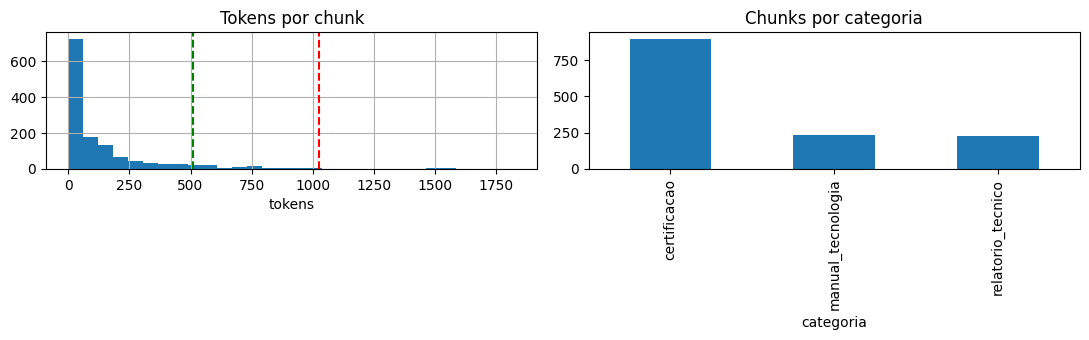

In [6]:
print('=== Relatorio de chunking ===')
print(f"Total de chunks ........ {len(df_chunks)}")
print(f"Tamanho medio (tokens) . {df_chunks['n_tokens'].mean():.1f}")
print(f"Min / Max tokens ....... {df_chunks['n_tokens'].min()} / {df_chunks['n_tokens'].max()}")
print(f"Chunks-tabela .......... {(df_chunks['tipo']=='tabela').sum()}")
print('\nDistribuicao por categoria:')
print(df_chunks.groupby('categoria').agg(chunks=('id','count'), tok_medio=('n_tokens','mean')).round(1))
print('\nDistribuicao por subcategoria:')
print(df_chunks.groupby('subcategoria')['id'].count())

import matplotlib.pyplot as plt
figura, eixos = plt.subplots(1, 2, figsize=(11, 3.5))
df_chunks['n_tokens'].hist(bins=30, ax=eixos[0])
eixos[0].axvline(TAMANHO_MINIMO_CHUNK, color='g', ls='--')
eixos[0].axvline(TAMANHO_MAXIMO_CHUNK, color='r', ls='--')
eixos[0].set_title('Tokens por chunk'); eixos[0].set_xlabel('tokens')
df_chunks['categoria'].value_counts().plot.bar(ax=eixos[1])
eixos[1].set_title('Chunks por categoria')
plt.tight_layout()
plt.savefig(os.path.join(DIRETORIO_SAIDAS, 'relatorio_chunking.png'), dpi=120)
plt.show()

## 5. Geracao de embeddings e indexacao em ChromaDB

Os embeddings sao gerados pelo `multilingual-e5-base` usando o prefixo `passage:` exigido pelo
modelo. A indexacao usa ChromaDB com persistencia em disco e armazena os metadados junto a cada
chunk, o que permite filtrar a busca por categoria ou subcategoria.

In [ ]:
from sentence_transformers import SentenceTransformer
import chromadb

modelo_embedding = SentenceTransformer(MODELO_EMBEDDING)

def gerar_embedding_passagens(textos):
    return modelo_embedding.encode(['passage: ' + texto for texto in textos],
                                   normalize_embeddings=True,
                                   show_progress_bar=True,
                                   convert_to_numpy=True)

def gerar_embedding_pergunta(pergunta):
    return modelo_embedding.encode(['query: ' + pergunta],
                                   normalize_embeddings=True,
                                   convert_to_numpy=True)[0]

cliente_chroma = chromadb.PersistentClient(path=DIRETORIO_CHROMA)
try:
    cliente_chroma.delete_collection('net_zero')
except Exception:
    pass
colecao = cliente_chroma.create_collection('net_zero', metadata={'hnsw:space': 'cosine'})

vetores = gerar_embedding_passagens(df_chunks['texto'].tolist())
metadados_chunks = df_chunks[['arquivo','fonte','categoria','subcategoria','ano','vigencia','tipo','n_tokens']].astype(str).to_dict('records')
colecao.add(ids=df_chunks['id'].tolist(),
            embeddings=vetores.tolist(),
            documents=df_chunks['texto'].tolist(),
            metadatas=metadados_chunks)
print(f'Indexados {colecao.count()} chunks em ChromaDB -> {DIRETORIO_CHROMA}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

## 6. Pipeline RAG com LLM local (Ollama)

A funcao `recuperar` busca os top-k chunks mais similares e aceita filtro opcional por metadado.
A funcao `responder` monta o contexto, aplica o prompt de sistema anti-alucinacao e chama o LLM
via Ollama exigindo citacao da fonte em cada afirmacao tecnica.

In [ ]:
import ollama

PROMPT_SISTEMA = (
    "Voce e um assistente tecnico especializado em edificios verdes e Net Zero de energia e agua. "
    "Responda exclusivamente com base nos trechos fornecidos no contexto. "
    "Se a informacao nao estiver no contexto, diga claramente: 'Nao encontrei essa informacao no corpus.'. "
    "Nunca invente dados, numeros ou normas. "
    "Para cada afirmacao tecnica cite a fonte entre colchetes no formato [fonte, ano]. "
    "Responda em portugues, de forma objetiva e tecnica."
)


def recuperar(pergunta, k=TOP_K, filtro=None):
    vetor_pergunta = gerar_embedding_pergunta(pergunta)
    resultado_busca = colecao.query(query_embeddings=[vetor_pergunta.tolist()],
                                    n_results=k, where=filtro,
                                    include=['documents', 'metadatas', 'distances'])
    chunks_recuperados = []
    for documento, metadado, distancia in zip(resultado_busca['documents'][0],
                                              resultado_busca['metadatas'][0],
                                              resultado_busca['distances'][0]):
        chunks_recuperados.append({'texto': documento, 'meta': metadado, 'score': 1 - distancia})
    return chunks_recuperados


def montar_contexto(chunks_recuperados):
    blocos = []
    for indice, chunk in enumerate(chunks_recuperados, 1):
        info = chunk['meta']
        blocos.append(f"[Trecho {indice} | fonte: {info['fonte']}, {info['ano']} | arquivo: {info['arquivo']}]\n{chunk['texto']}")
    return '\n\n---\n\n'.join(blocos)


def responder(pergunta, k=TOP_K, filtro=None, modelo=MODELO_LLM):
    chunks_recuperados = recuperar(pergunta, k=k, filtro=filtro)
    contexto = montar_contexto(chunks_recuperados)
    mensagem_usuario = f"CONTEXTO:\n{contexto}\n\nPERGUNTA: {pergunta}\n\nResponda citando as fontes [fonte, ano]."
    resposta_llm = ollama.chat(model=modelo, messages=[
        {'role': 'system', 'content': PROMPT_SISTEMA},
        {'role': 'user', 'content': mensagem_usuario}
    ], options={'temperature': 0.1})
    texto_resposta = resposta_llm['message']['content']
    fontes_citadas = sorted({f"{c['meta']['fonte']} ({c['meta']['ano']}) - {c['meta']['arquivo']}"
                             for c in chunks_recuperados})
    return {'pergunta': pergunta, 'resposta': texto_resposta,
            'fontes': fontes_citadas, 'hits': chunks_recuperados}

In [ ]:
resultado = responder('Como funciona o reaproveitamento de aguas cinzas em edificios?')
print(resultado['resposta'])
print('\nFONTES:')
for fonte in resultado['fontes']:
    print(' -', fonte)

In [ ]:
print('--- Recuperacao filtrada por subcategoria=agua ---')
for chunk in recuperar('captacao de agua da chuva', k=3, filtro={'subcategoria': 'agua'}):
    print(f"  score={chunk['score']:.3f}  {chunk['meta']['arquivo']}  ({chunk['meta']['categoria']})")

## 7. Avaliacao do sistema

As dez perguntas de `perguntas_teste.json` sao executadas pelo RAG e o resultado e salvo em
`saidas/avaliacao_rag.md`. Tres dessas perguntas sao tambem respondidas pelo LLM sem contexto RAG
para evidenciar diferencas em precisao, rastreabilidade e ocorrencia de alucinacao.

In [ ]:
with open(os.path.join(DIRETORIO_BASE, 'perguntas_teste.json'), encoding='utf-8') as arquivo:
    banco_perguntas = json.load(arquivo)

linhas_avaliacao = ['# Avaliacao RAG — 10 perguntas\n']
registros_avaliacao = []
for pergunta in banco_perguntas['perguntas']:
    resultado = responder(pergunta['pergunta'])
    linhas_avaliacao.append(f"## {pergunta['id']} ({pergunta['subcategoria']}) — {pergunta['pergunta']}\n")
    linhas_avaliacao.append(resultado['resposta'] + '\n')
    linhas_avaliacao.append('**Fontes citadas:**')
    linhas_avaliacao += [f"- {fonte}" for fonte in resultado['fontes']]
    linhas_avaliacao.append('\n**Verificacao manual:** [ ] info confere com a fonte\n')
    registros_avaliacao.append({'id': pergunta['id'],
                                'sub': pergunta['subcategoria'],
                                'pergunta': pergunta['pergunta'],
                                'top_fonte': resultado['hits'][0]['meta']['arquivo'],
                                'score': round(resultado['hits'][0]['score'], 3)})

with open(os.path.join(DIRETORIO_SAIDAS, 'avaliacao_rag.md'), 'w', encoding='utf-8') as arquivo:
    arquivo.write('\n'.join(linhas_avaliacao))
print('Salvo: saidas/avaliacao_rag.md')
pd.DataFrame(registros_avaliacao)

In [ ]:
def responder_sem_rag(pergunta, modelo=MODELO_LLM):
    resposta_llm = ollama.chat(model=modelo, messages=[
        {'role': 'system', 'content': 'Voce e um assistente tecnico. Responda em portugues.'},
        {'role': 'user', 'content': pergunta}
    ], options={'temperature': 0.1})
    return resposta_llm['message']['content']


ids_para_comparar = banco_perguntas['metadata']['comparar_sem_rag']
linhas_comparacao = ['# Comparacao RAG vs LLM puro\n']
for pergunta in [p for p in banco_perguntas['perguntas'] if p['id'] in ids_para_comparar]:
    resposta_com_rag = responder(pergunta['pergunta'], filtro={'subcategoria': pergunta['subcategoria']})
    resposta_sem_rag = responder_sem_rag(pergunta['pergunta'])
    linhas_comparacao += [
        f"## {pergunta['id']} — {pergunta['pergunta']}\n",
        '### Com RAG', resposta_com_rag['resposta'],
        '\n**Fontes:** ' + '; '.join(resposta_com_rag['fontes']),
        '\n### Sem RAG (LLM puro)', resposta_sem_rag,
        '\n**Analise:** precisao / rastreabilidade / alucinacao\n', '---\n'
    ]

with open(os.path.join(DIRETORIO_SAIDAS, 'comparacao_rag_vs_puro.md'), 'w', encoding='utf-8') as arquivo:
    arquivo.write('\n'.join(linhas_comparacao))
print('Salvo: saidas/comparacao_rag_vs_puro.md')

## 8. Visualizacao t-SNE e insumos do relatorio critico

Projecao t-SNE em 2D dos embeddings, colorida por categoria, para inspecionar a qualidade dos
clusters semanticos. Ao final, sao impressas estatisticas-resumo que alimentam o relatorio
critico em `relatorio/relatorio_critico.md`.

In [ ]:
from sklearn.manifold import TSNE
perplexidade = max(5, min(30, len(vetores) // 3))
projecao_2d = TSNE(n_components=2, perplexity=perplexidade, init='pca', random_state=42).fit_transform(vetores)

plt.figure(figsize=(8, 6))
for categoria in df_chunks['categoria'].unique():
    mascara = (df_chunks['categoria'] == categoria).values
    plt.scatter(projecao_2d[mascara, 0], projecao_2d[mascara, 1], label=categoria, alpha=0.7, s=18)
plt.legend()
plt.title('t-SNE dos chunks por categoria')
plt.tight_layout()
plt.savefig(os.path.join(DIRETORIO_SAIDAS, 'tsne_categorias.png'), dpi=120)
plt.show()

In [ ]:
print('=== Insumos do relatorio critico ===')
print(f"Documentos no corpus ....... {len(metadados)}")
print(f"Categorias ................. {dict(metadados['categoria'].value_counts())}")
print(f"Total de chunks ............ {len(df_chunks)}")
print(f"Tokens/chunk (medio) ....... {df_chunks['n_tokens'].mean():.1f}")
print(f"Perguntas avaliadas ........ {len(banco_perguntas['perguntas'])}")
print(f"Perplexity t-SNE ........... {perplexidade}")
print('\nScore medio do top-1 por pergunta:', round(np.mean([r['score'] for r in registros_avaliacao]), 3))
print('Perguntas com top-1 score < 0.80:')
for registro in registros_avaliacao:
    if registro['score'] < 0.80:
        print('  -', registro['id'], registro['pergunta'])

### Como rodar (resumo)
1. `pip install -r requirements.txt` e `ollama pull qwen2.5:3b`
2. Coloque ao menos 10 documentos em `corpus/` e preencha `metadata.csv`
3. Execute este notebook celula a celula
4. Saidas em `saidas/`: relatorio de chunking, avaliacao, comparacao e t-SNE
5. Escreva o relatorio critico em `relatorio/relatorio_critico.md`